In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [3]:
basepath_kathy='/data/esplab/kpegion/projects/AGCM_Experiments/AC_Test/'
#basepath_kathy2='/data/esplab/kpegion/projects/AGCM_Experiments/AC_noheating/'
basepath_kathy2='/data/esplab/kpegion/projects/AGCM_Experiments/AC_warm/'

basepath_ben='/data/esplab/shared/model/uninitialized/GammaT63L26AC/'

DataSetname = ['geo']
Dataname = ['geo']

In [4]:
fnames_kathy=basepath_kathy+'geo'+'_Pressure_*.nc'
fnames_kathy2=basepath_kathy2+'geo'+'_Pressure_*.nc'
fnames_ben=basepath_ben+'geo'+'_Pressure_*.nc'

In [5]:
ds_kathy=xr.open_mfdataset(fnames_kathy).sel(lev=500)/9.81
ds_kathy2=xr.open_mfdataset(fnames_kathy2).sel(lev=500)/9.81
ds_ben=xr.open_mfdataset(fnames_ben).sel(lev=500)/9.81
dsk=ds_kathy['geo'].mean(dim='time')
dsk2=ds_kathy2['geo'].mean(dim='time')
dsb=ds_ben['geo'].mean(dim='time')

/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
ds_kathy

<xarray.Dataset>
Dimensions:  (time: 6540, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-01-02 ... 1967-12-27
    lev      float64 500.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
Data variables:
    geo      (time, lat, lon) float64 dask.array<chunksize=(6540, 96, 192), meta=np.ndarray>

In [7]:
ds_ben

<xarray.Dataset>
Dimensions:  (time: 10800, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-01-02 ... 1979-07-27
    lev      float64 500.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
Data variables:
    geo      (time, lat, lon) float64 dask.array<chunksize=(10800, 96, 192), meta=np.ndarray>

In [8]:
ds_kathy2

<xarray.Dataset>
Dimensions:  (time: 2160, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-01-02 ... 1955-11-30
    lev      float64 500.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
Data variables:
    geo      (time, lat, lon) float64 dask.array<chunksize=(2160, 96, 192), meta=np.ndarray>

In [9]:
dsk

<xarray.DataArray 'geo' (lat: 96, lon: 192)>
dask.array<mean_agg-aggregate, shape=(96, 192), dtype=float64, chunksize=(96, 192), chunktype=numpy.ndarray>
Coordinates:
    lev      float64 500.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1

In [10]:
dsb

<xarray.DataArray 'geo' (lat: 96, lon: 192)>
dask.array<mean_agg-aggregate, shape=(96, 192), dtype=float64, chunksize=(96, 192), chunktype=numpy.ndarray>
Coordinates:
    lev      float64 500.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1

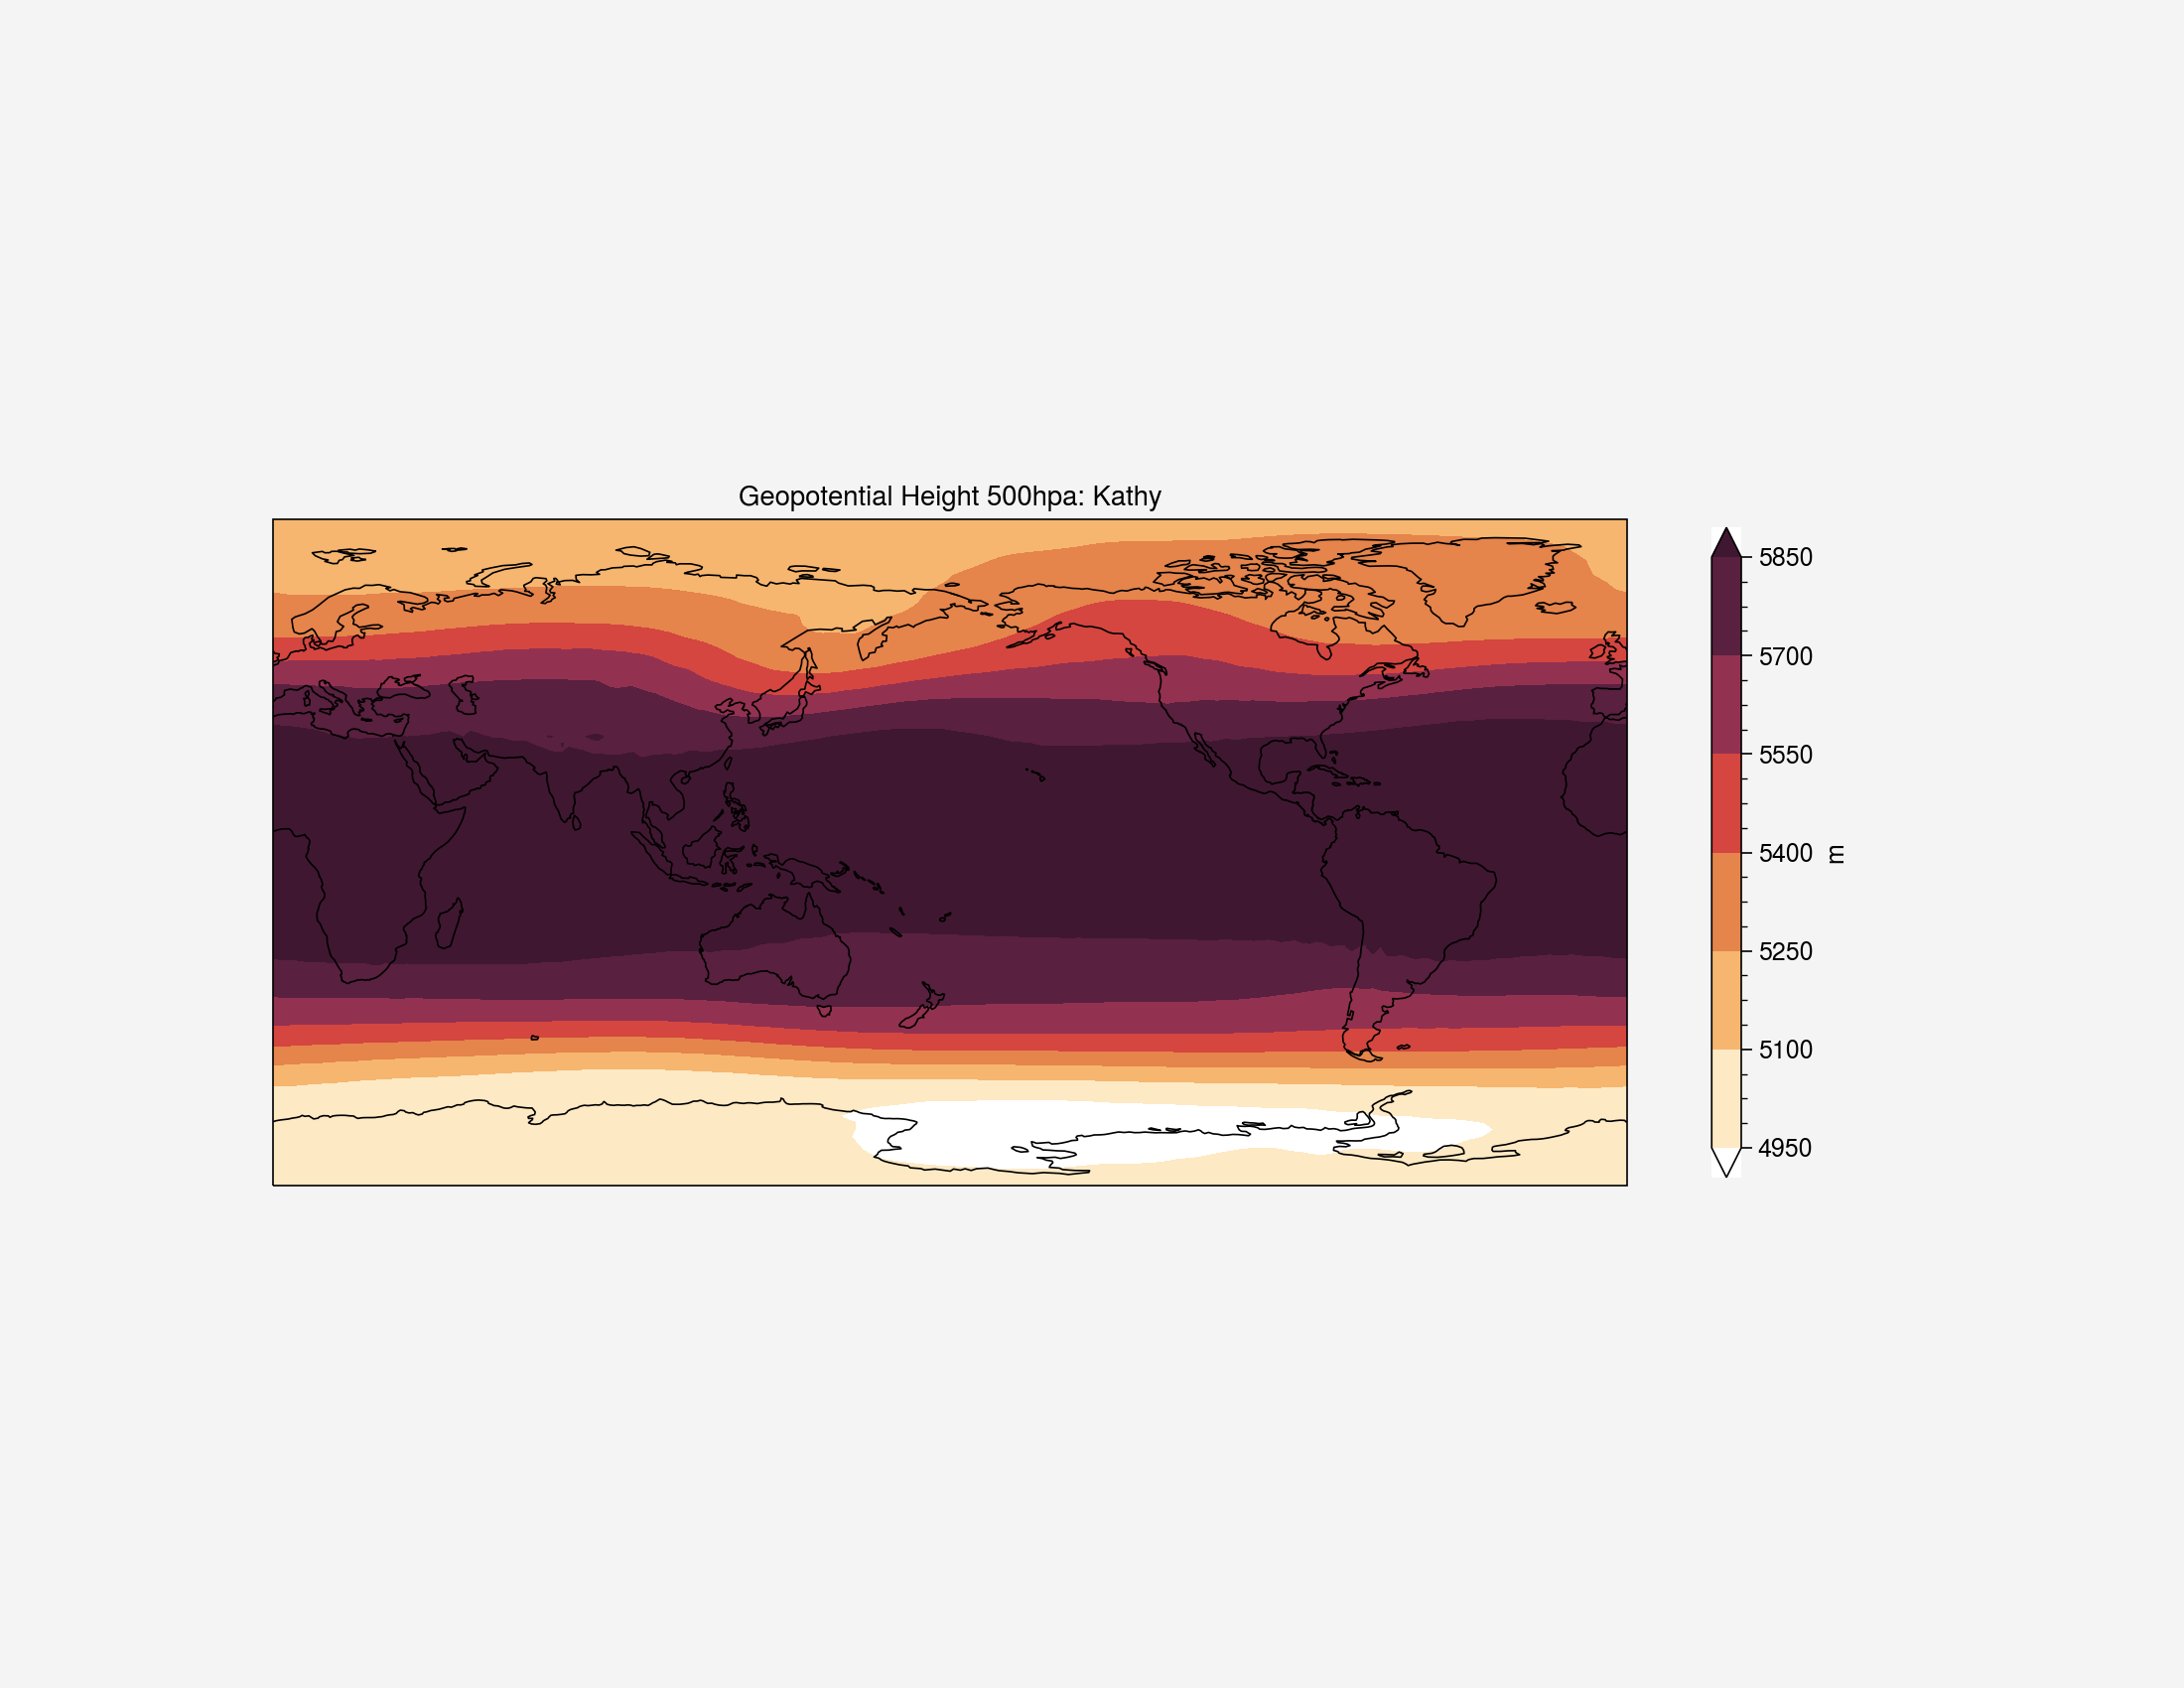

In [11]:
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data, lons = add_cyclic_point(dsk, coord=dsk['lon'])
cs=ax.contourf(lons, dsk['lat'],data,transform = ccrs.PlateCarree(),
               extend='both')
ax.coastlines()
plt.title('Geopotential Height 500hpa: Kathy')
plt.colorbar(cs,shrink=0.5,label='m')

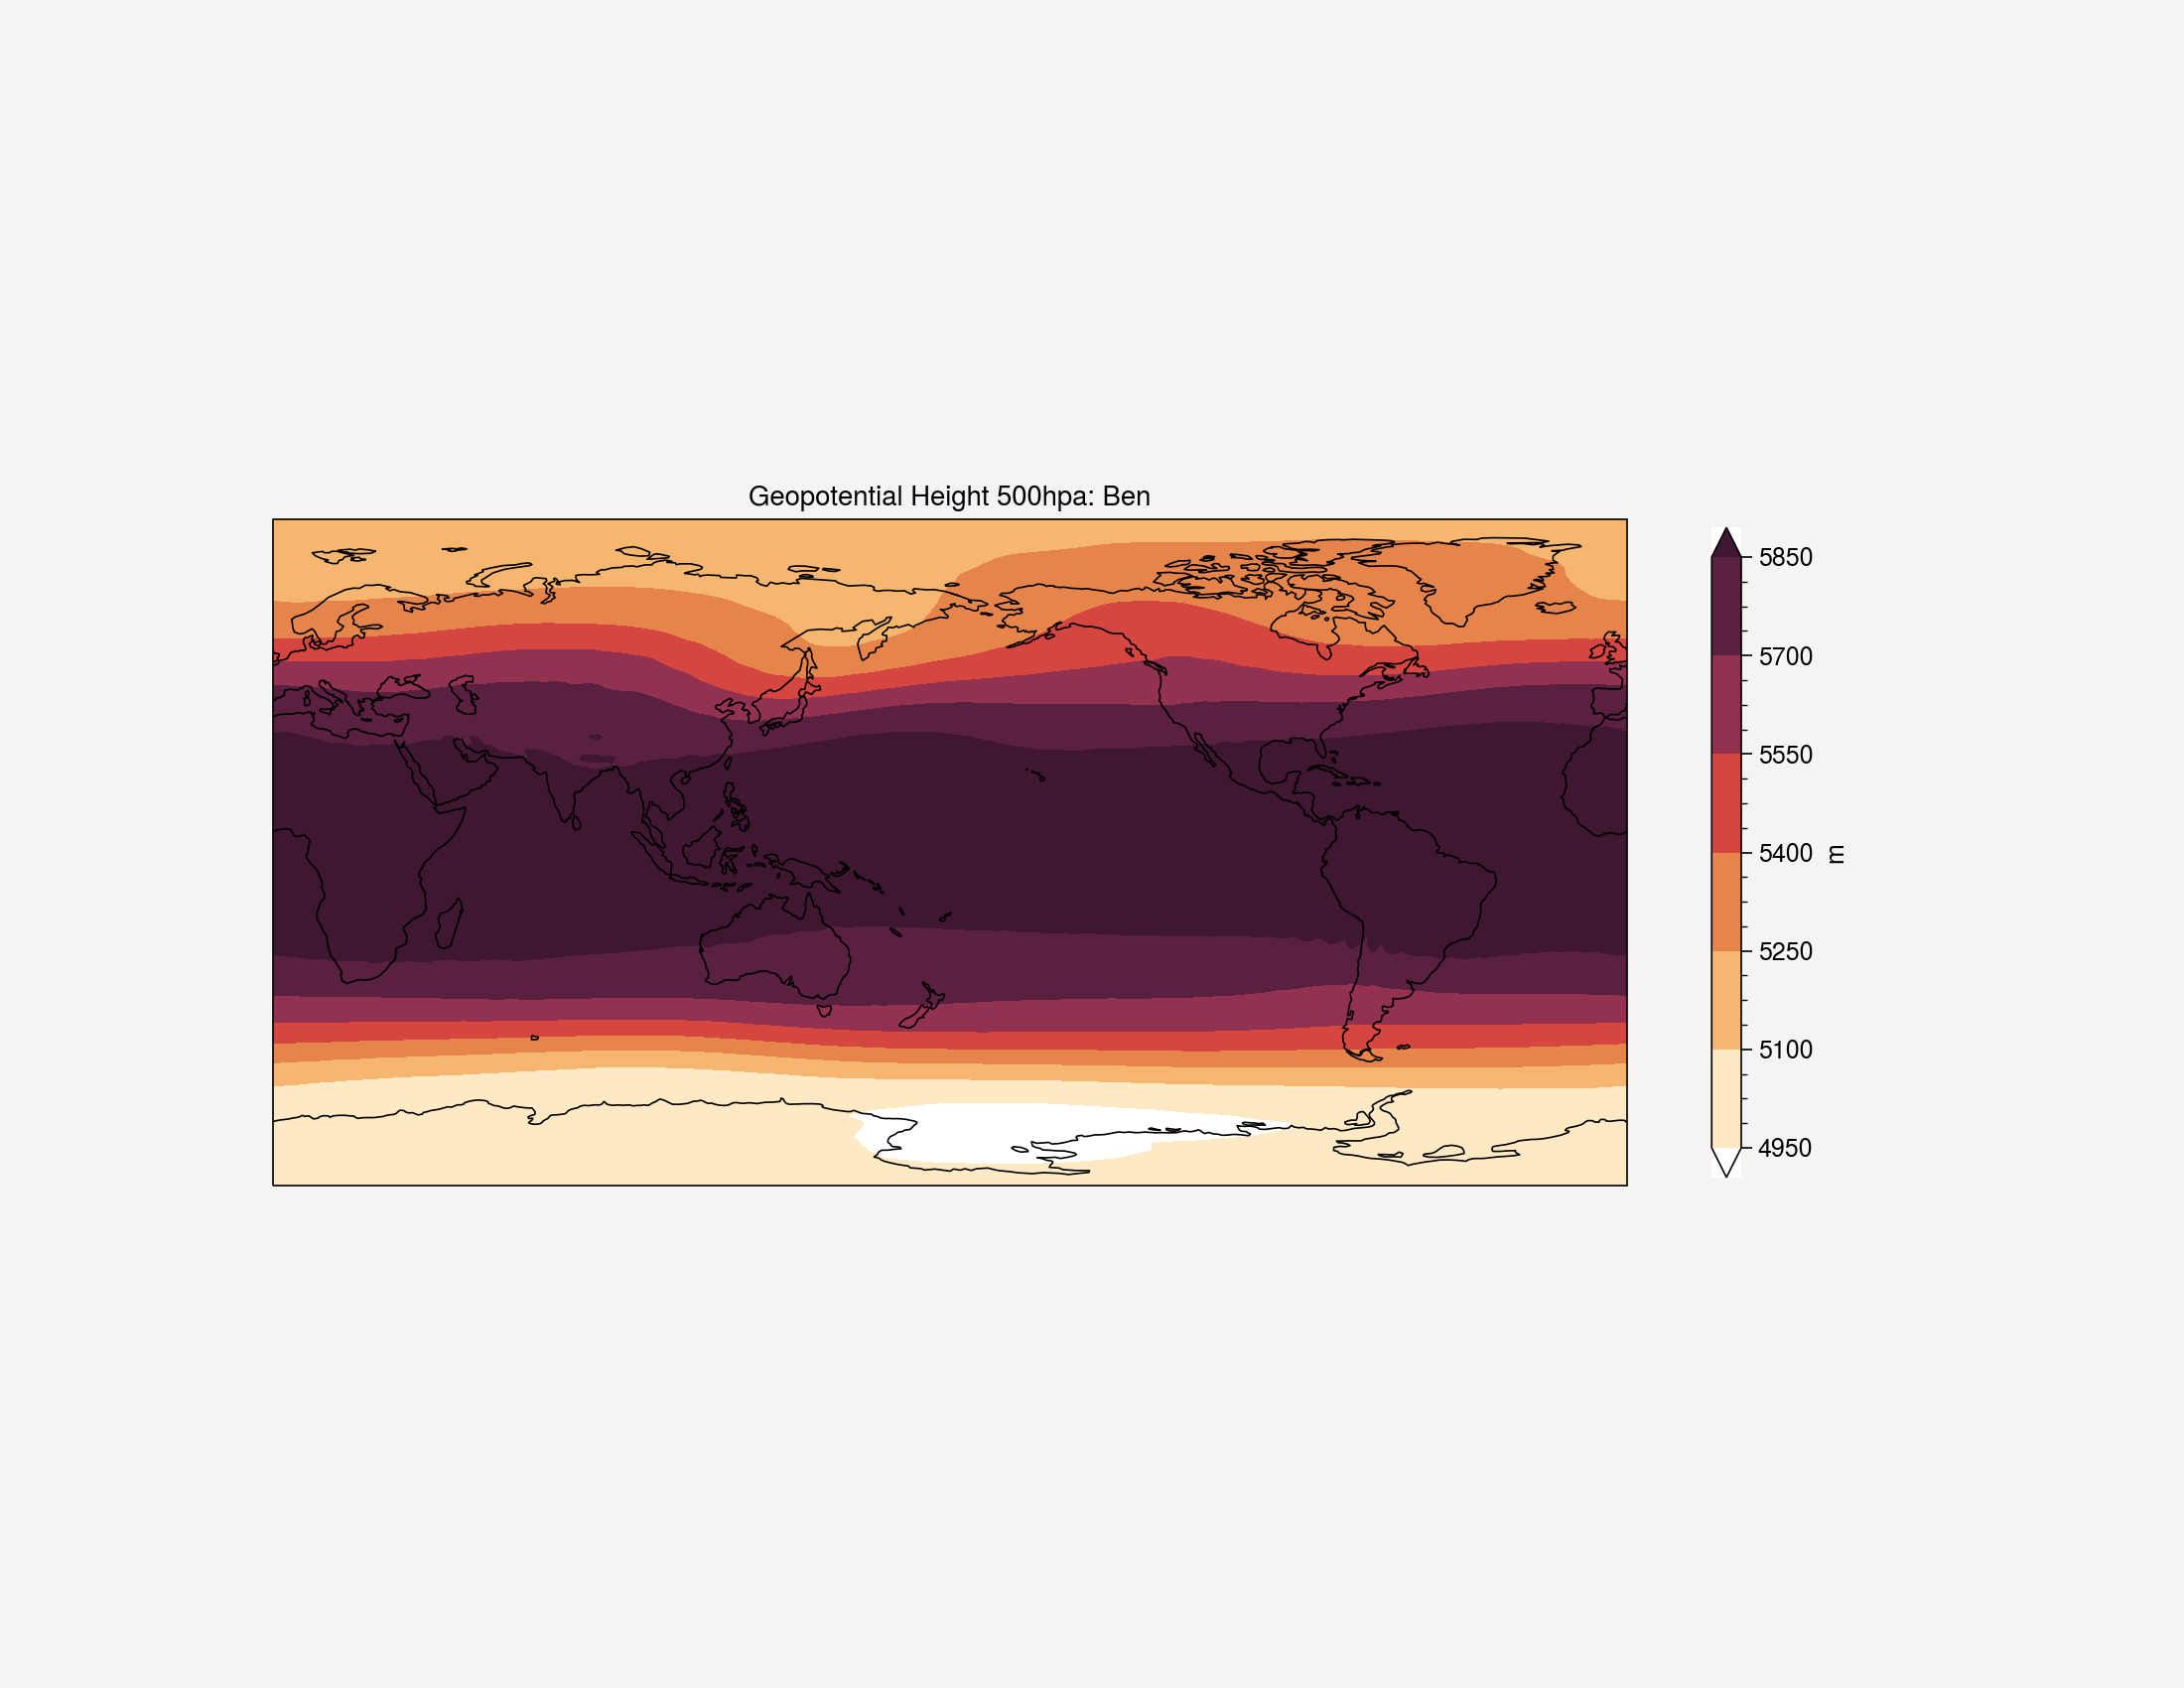

In [12]:
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data, lons = add_cyclic_point(dsb, coord=dsb['lon'])
cs=ax.contourf(lons, dsb['lat'],data,transform = ccrs.PlateCarree(),
               extend='both')
ax.coastlines()
plt.title('Geopotential Height 500hpa: Ben')
plt.colorbar(cs,shrink=0.5,label='m')

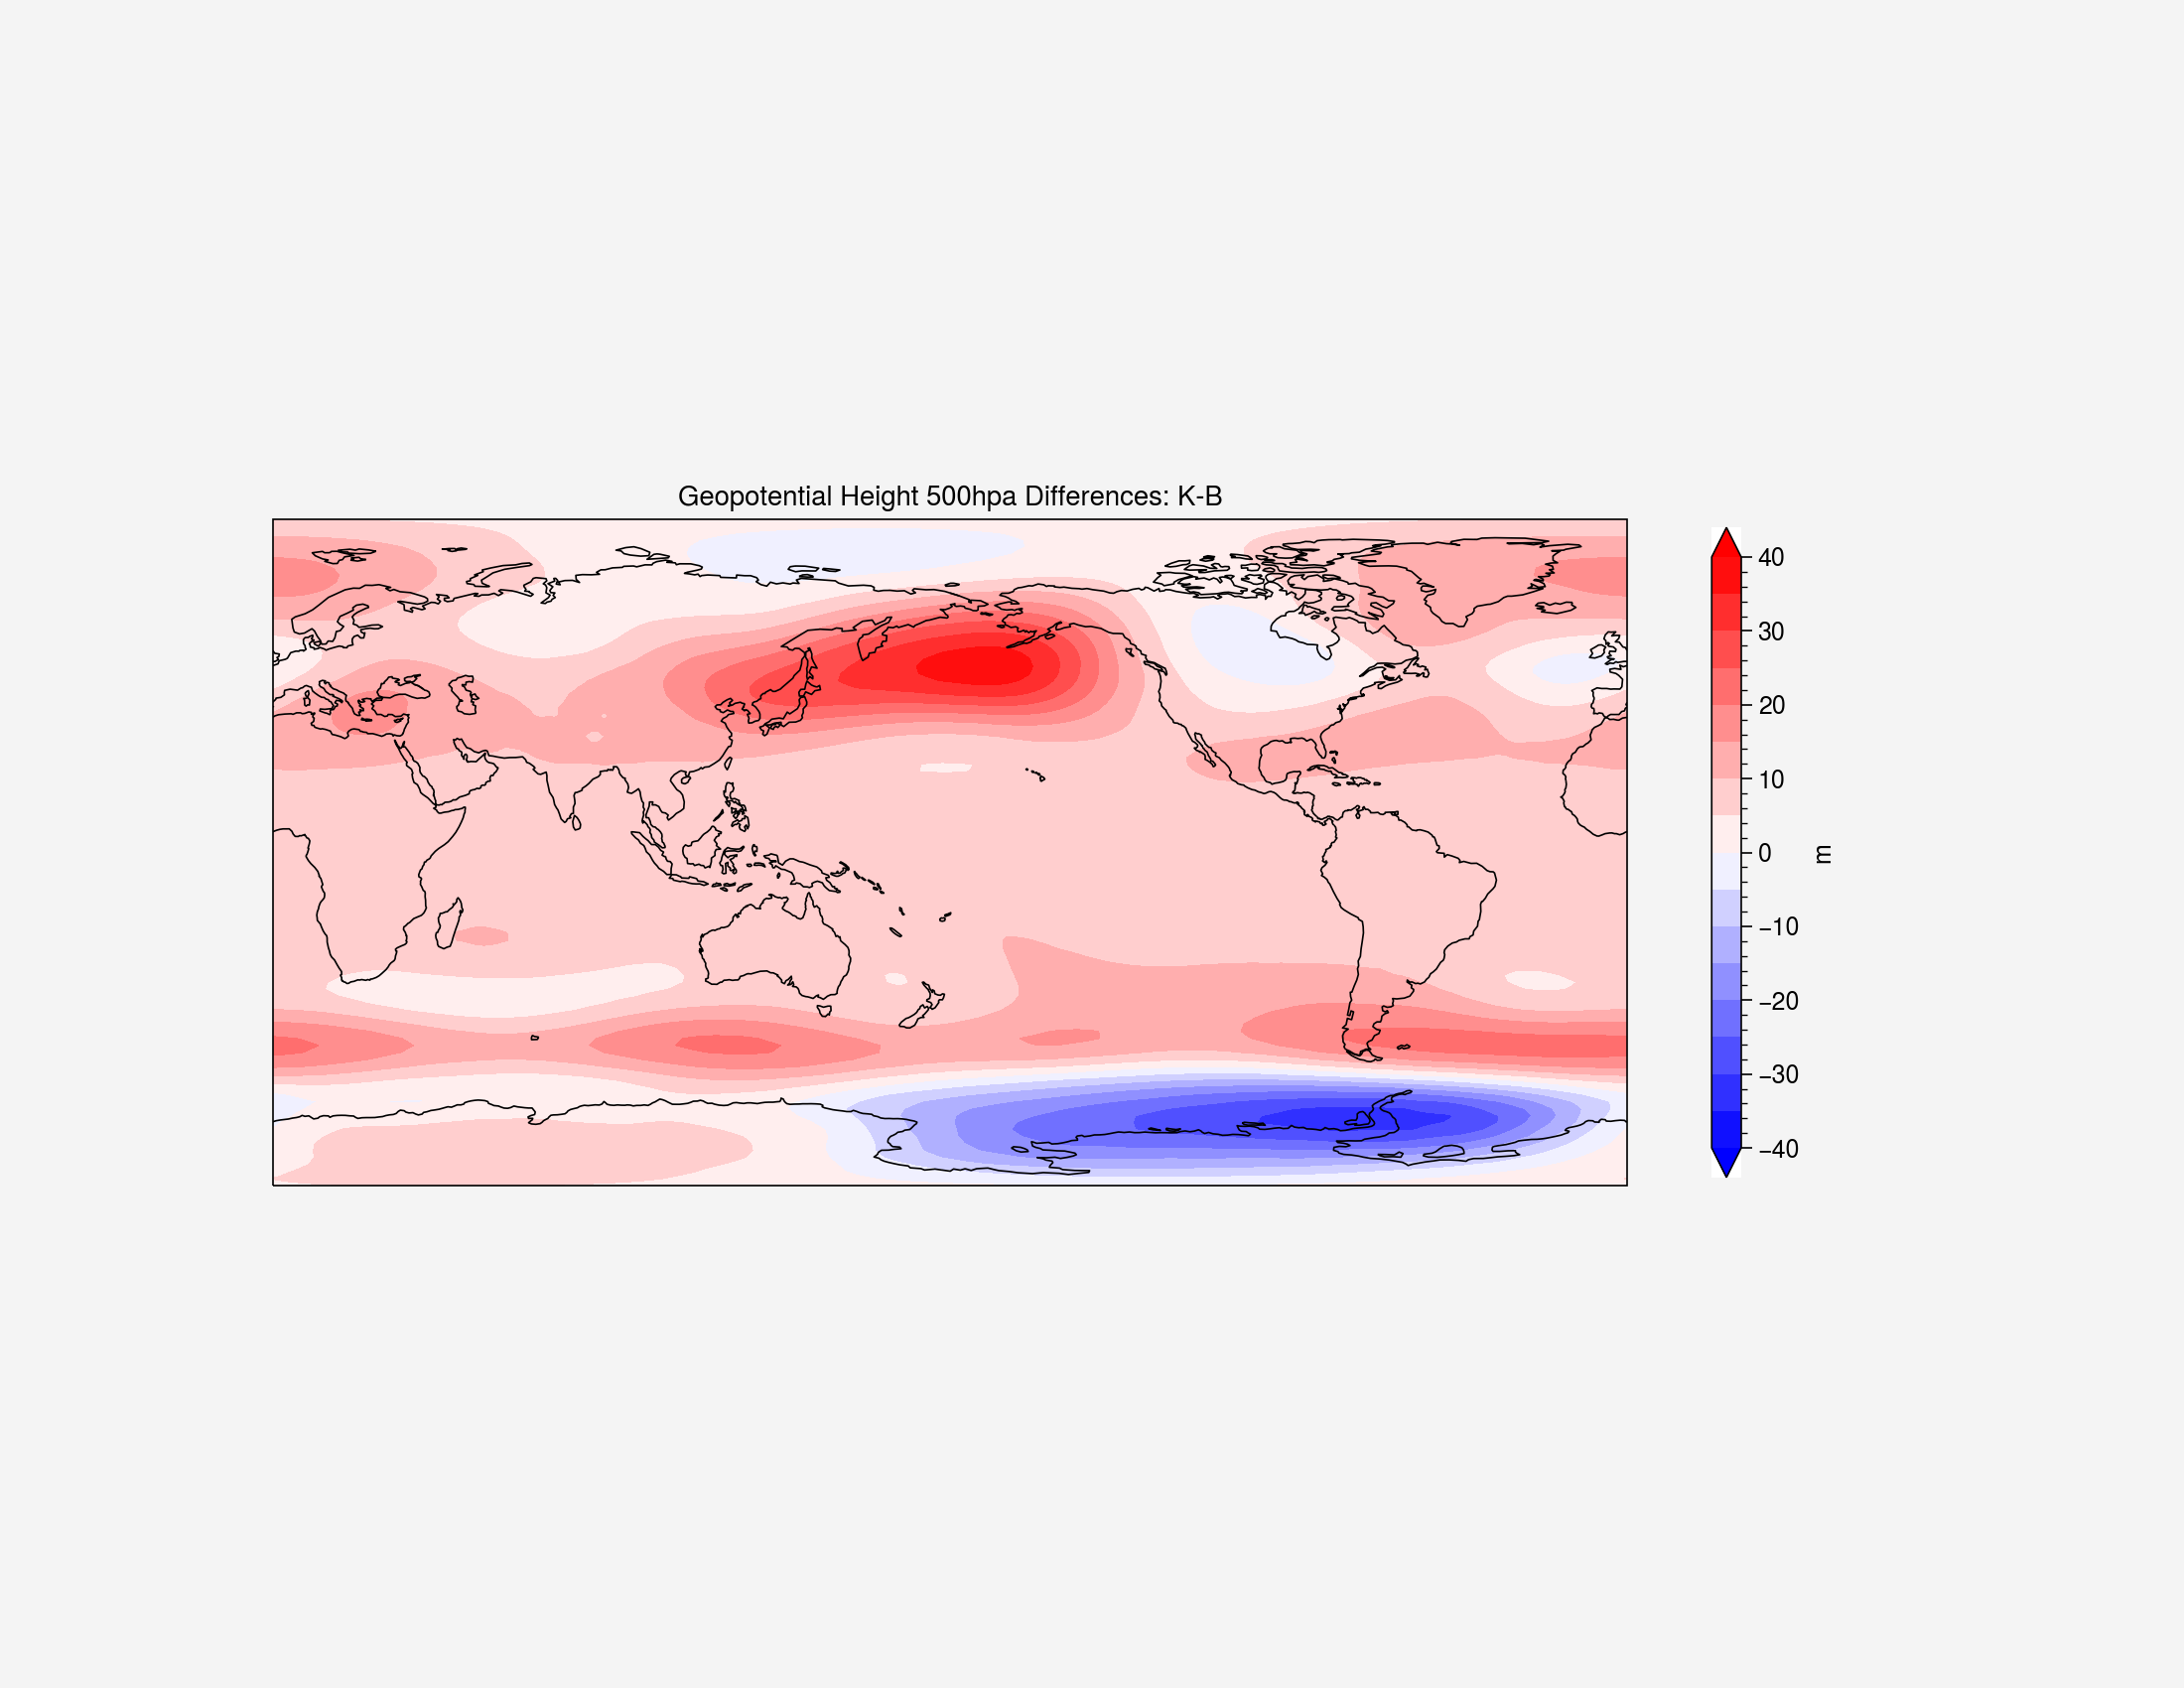

In [13]:
diff=dsk-dsb
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data, lons = add_cyclic_point(diff, coord=diff['lon'])
cs=ax.contourf(lons, diff['lat'],data,transform = ccrs.PlateCarree(),
               levels=np.arange(-40,41,5),extend='both',cmap='bwr')
ax.coastlines()
plt.title('Geopotential Height 500hpa Differences: K-B')
plt.colorbar(cs,shrink=0.5,label='m')

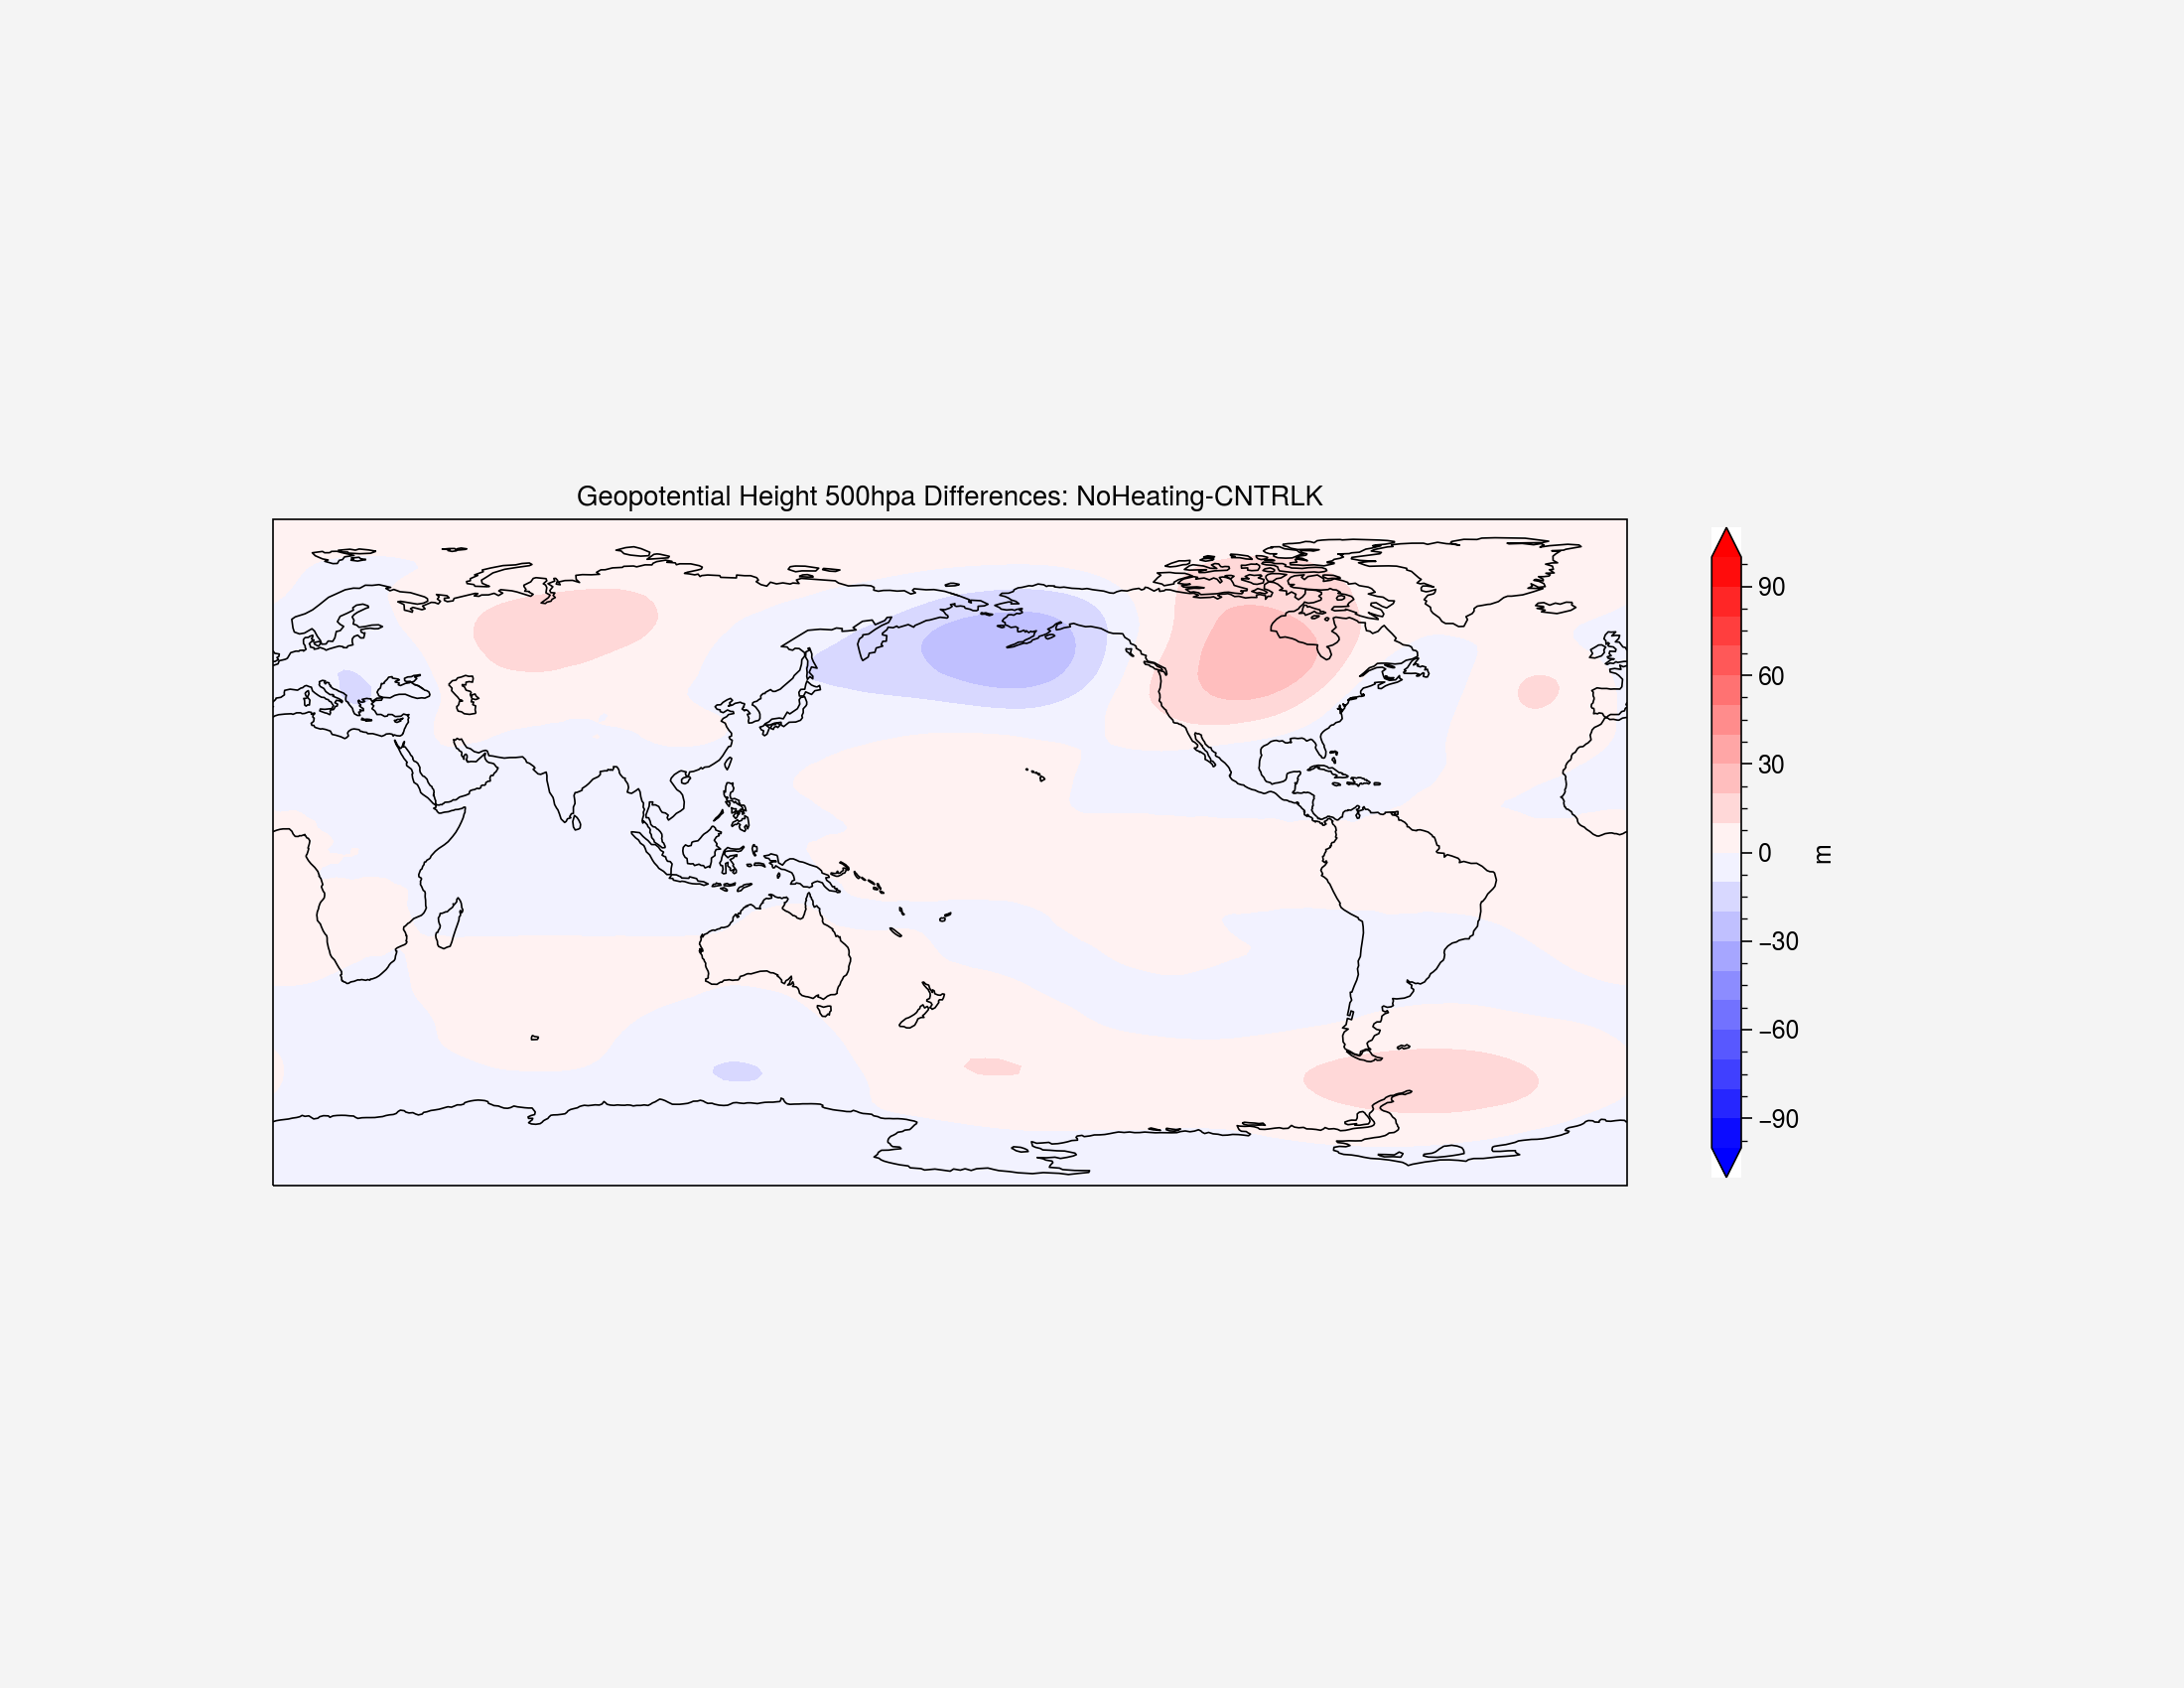

In [14]:
diff2=dsk2-dsk
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data, lons = add_cyclic_point(diff2, coord=diff['lon'])
cs=ax.contourf(lons, diff['lat'],data,levels=np.arange(-100,101,10),transform = ccrs.PlateCarree(),
               cmap='bwr',extend='both')
ax.coastlines()
plt.title('Geopotential Height 500hpa Differences: NoHeating-CNTRLK')
plt.colorbar(cs,shrink=0.5,label='m')